# Triangulation theoretical analysis

We know that the eigenvectors of the Strain matrix of the selected flow are strictly connected with the strategy success. The eigenvector $\textbf{e}_1$ associated to the maximum eigenvalue points in the direction average of all directions determined by the agent. 

We therefore use the direction $\hat{\textbf{e}}_1$ as the optimal direction inferred by the agent.

# imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyquaternion import Quaternion
from mpl_toolkits.mplot3d import Axes3D
import matplotlib
"""
matplotlib.rcParams.update({'font.size': 20})
rc_fonts = {
    "font.family": "serif",
    "font.size": 20,
    'figure.figsize': (5, 3),
    "text.usetex": True
}
matplotlib.rcParams.update(rc_fonts)
"""
import sys 
sys.path.append("../General_Functions/")

from Flow_functions import *
from Geometric_functions import *
from Strategies import Triangulation3D


In [16]:
# We use here a reference system oriented as zxy
grads = [GradientStresslet]  # StrainStresslet # Note: it should work with a strain or another flow
grad_names = ["GradientStresslet"] # StrainStresslet # For saving porpouses
flow = FlowStokeslet
e = np.array([1, 0, 0])  # orientation of the flow
Nagent = 100  # number of agent positions (in the quarter circle of radius 1)
Npoints = 61 # Resolution of space sampling
NTrials = 50 
dt = .1 # timestep lenght
AntennaeLength = .01 # Half inter-sensors distance
twist = 0.3 # Rotation around swimming direction t
x = np.linspace(0.1, 5, Npoints) # x axis position of the agent
z = np.linspace(0.1, 5, Npoints) # z axis position of the agent
X, Z = np.meshgrid(x, z) # Create 2D grid



# Flow strains

Calculate eigenvectors and eigenvalues of the flow Strain Matrix

In [17]:
# tensor gradient in coordinates xyz
def Define_strain_eigenvectors(Grad, e3, AgentPosition):
    G = Grad(e3, AgentPosition)
    assert np.isclose(np.trace(G), 0), "gradient is not trace free"
    #assert np.allclose(G, np.transpose(G)), "gradient is not symmetric"

    # calculations of eigenvectors and relative eigenvalue a
    vaps, veps = np.linalg.eig(G[:-1,:-1])

    i_max = np.argmax(np.abs(vaps))
    s = np.sum(vaps) / vaps[i_max] - 1
    
    if np.abs(G[2,2]) > np.max(np.abs(vaps)):
        print("Greater eigenvalue is along e_phi")
        
    # calculation of the trajectories of t as ellipses
    ymax = np.cos(0.5 * np.arccos(s / (2 + s)))
    zmax = np.cos(0.5 * np.arccos((s + 1) / (s - 1)))
    
    n0 = np.array([0,0,1])
    n2 = np.append(veps[:,i_max], 0) 
    n2 *= np.sign(np.dot(n2, - AgentPosition))
    n1 = np.cross(n2, n0)
    
    return s, ymax, zmax, n0, n1, n2


# tensor gradient in coordinates xyz
def Define_a1a2_strain_eigenvectors(Grad, e3, AgentPosition):
    G = Grad(e3, AgentPosition)

    # Find eigenvalues and eigenvectors of the sym part
    symG = 0.5 * (G + G.T)
    vaps, veps = np.linalg.eigh(symG)
    
    # Sort eigenvalues by absolute value (descending)
    idx_sorted = np.argsort(np.abs(vaps))[::-1]
    vaps = vaps[idx_sorted]
    veps = veps[:, idx_sorted]
   
    # Define e1 as the eigenvector with the largest |eigenvalue|
    e1 = veps[:, 0]
    e1 = e1 / np.linalg.norm(e1)
   
    # Find e3 as the vector orthogonal to AgentPosition
    AgentPos_norm = AgentPosition / np.linalg.norm(AgentPosition)    
    for i in range(3):
        vi = veps[:, i]
        if np.abs(np.dot(vi, AgentPos_norm)) < 1e-6:  # numerically orthogonal
            e3 = vi / np.linalg.norm(vi)
            break
    else:
        raise ValueError("No eigenvector orthogonal to AgentPosition found.")
    
    # Make sure e1 and e3 are orthogonal
    if np.abs(np.dot(e1,e3)) > 1e-6:
        raise ValueError("Eigenvectors e1 and e3 not orthogonal")
    
    # Choose the sign of e1 
    e1 *= np.sign(np.dot(e1, - AgentPosition))
    
    # Define e2 = e3 × e1 to complete right-handed orthonormal basis
    e2 = np.cross(e1, e3)
    e2 /= np.linalg.norm(e2)
    
    # Assemble the rotation matrix B = [e1 | e2 | e3]
    B = np.stack([e1, e2, e3], axis=-1)  # shape (3, 3)
    
    # Change basis: express G in new basis (This is the matrix appearing in the paper)
    G_new = (B.T @ G @ B) / vaps[0] # shape (3,3)

    s = G_new[1,1]
    Omega = G_new[0,1]
    if s/(s-1) < 0:
        asd
    # Major and minor semi-axes of the ellipse
    if abs(vaps[1]) != (vaps[2]):
        a2 = np.sqrt(abs(s / (s-1)))
        a3 = np.sqrt(abs((s**2 + s) / (s**2 + 2*s + Omega**2)))
    else:
        a2 = a3 = np.sqrt(abs(vaps[1]))
        
    # Same for n's
    #b2 = np.sqrt(1 / (1-s))
    #b3 = np.sqrt(1 / (2+s))
    
    return a2, a3


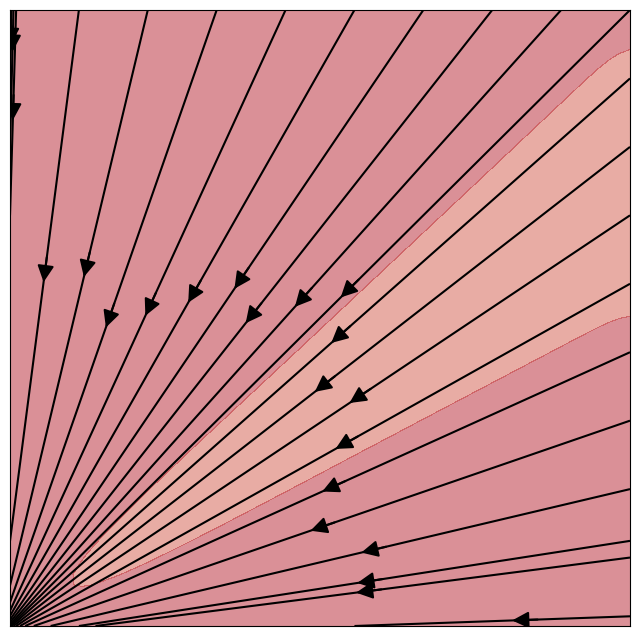

In [18]:
from scipy import ndimage
Direction_n2_x =  np.zeros((Npoints,Npoints))
Direction_n2_z =  np.zeros((Npoints,Npoints))
P_Theory = np.zeros((Npoints,Npoints))

# Compute optimal direction
for grads_i in range(len(grads)):
    for i in range(X.shape[0]):
        for j in range(X.shape[0]):
            AgentPosition = np.array([Z[i,j], X[i,j], 0])
            if np.sqrt(X[i,j]**2 + Z[i,j]**2) < 0.1:
                    Direction_n2_x[i,j] = 0
                    Direction_n2_z[i,j] = 0
            else:
                a2, a3 = Define_a1a2_strain_eigenvectors(grads[grads_i], e, AgentPosition)
                _, ymax, zmax, _, _, e_2 = Define_strain_eigenvectors(grads[grads_i], e, AgentPosition)
                Direction_n2_x[i, j] = e_2[1]
                Direction_n2_z[i, j] = e_2[0]
                r1 = np.dot(e_2, -AgentPosition/np.linalg.norm(AgentPosition))
                if a2*a3 < 1:
                    P_Theory[i, j] = r1 * np.sqrt(1 - a2*a3)
                else:
                     P_Theory[i, j] = r1 
# Plot
P_Theory = ndimage.gaussian_filter(P_Theory, sigma=2.0, order=0)
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (8, 8), sharex = 'col', sharey = 'row')
axs.streamplot(X, Z, Direction_n2_x, Direction_n2_z, density = .35, color  = 'black', arrowsize = 2.5, broken_streamlines=False)
#axs.contour(X, Z, Std, cmap  = 'RdBu_r', alpha = .5)
levels = np.linspace(-1, 1.00001, 14)
im = axs.contourf(X, Z, P_Theory, cmap = 'RdBu_r', levels = levels, vmin= -1, vmax = 1, alpha = 0.5)
# PlotCircles(axs, 0.6)
axs.set_xlim([0.1,5])
axs.set_ylim([0.1,5])
axs.set_xticks([])
axs.set_yticks([])
plt.savefig(f"Plots/Triangulation_theoretical_{grad_names[0]}.pdf", bbox_inches='tight')

In [ ]:
# Plot only arrays

C:\Users\Redaelli\AppData\Local\Temp\ipykernel_22984\226272806.py:18: ComplexWarning: Casting complex values to real discards the imaginary part
  Direction_n2_x[i, j] = e_2[1]
C:\Users\Redaelli\AppData\Local\Temp\ipykernel_22984\226272806.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  Direction_n2_z[i, j] = e_2[0]
C:\Users\Redaelli\AppData\Local\Temp\ipykernel_22984\653569960.py:18: RuntimeWarning: invalid value encountered in arccos
  zmax = np.cos(0.5 * np.arccos((s + 1) / (s - 1)))


Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenvalue is along e_phi
Greater eigenv

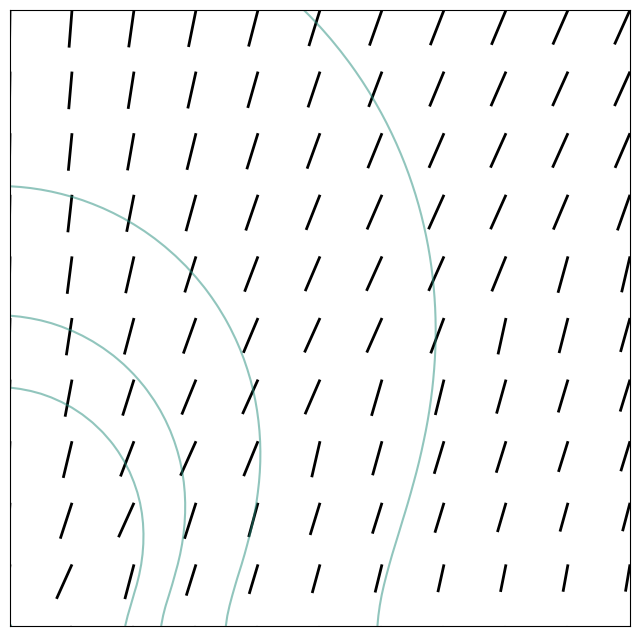

In [25]:
from matplotlib.collections import LineCollection


# --- Your existing arrays ---
Direction_n2_x =  np.zeros((Npoints,Npoints))
Direction_n2_z =  np.zeros((Npoints,Npoints))
Flow = np.zeros((Npoints,Npoints))

# Compute optimal direction
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        AgentPosition = np.array([Z[i,j], X[i,j], 0])
        if np.sqrt(X[i,j]**2 + Z[i,j]**2) < 0.2:
            Direction_n2_x[i,j] = 0
            Direction_n2_z[i,j] = 0
        else:
            _, ymax, zmax, _, _, e_2 = Define_strain_eigenvectors(grad, e, AgentPosition)
            Direction_n2_x[i, j] = e_2[1]
            Direction_n2_z[i, j] = e_2[0]
            Flow[i, j] = np.linalg.norm(flow(e, np.array([Z[i,j],X[i,j],0])))

# --- Convert directions to segments ---
segments = []
step = 6
for i in range(0, Npoints, step):
    for j in range(0, Npoints, step):
        x0, z0 = X[i,j], Z[i,j]
        dx, dz = Direction_n2_x[i,j], Direction_n2_z[i,j]
        # Scale the vector for visualization if needed
        scale = 0.3
        segments.append([[x0, z0], [x0 + dx*scale, z0 + dz*scale]])

# --- Plot ---
fig, axs = plt.subplots(figsize=(8,8))

# Line thickness and color
line_thickness = 2
line_color = 'black'

lc = LineCollection(segments, linewidths=line_thickness, colors=line_color)
axs.add_collection(lc)

# Optional: contour background
levels = np.linspace(-1, 1.00001, 10)
im = axs.contour(X, Z, Flow, colors='#258D7C', levels=levels, vmin=-1, vmax=1, alpha=0.5)

axs.set_xlim([0.1,5])
axs.set_ylim([0.1,5])
axs.set_xticks([])
axs.set_yticks([])

plt.savefig(f"Plots/Triangulation_theoretical_{grad_name}_e1.pdf", bbox_inches='tight')
plt.show()

Do it for any point in the domain 
Crea una funzione per tornare eigenvector e eigenvalue
Crea una funzione per calcolarci le robe 
prodotto scalare basta tra eigenvector e direzione ideale direi


# Flow gradients

In [2]:
grad = GradientStresslet  # StrainStresslet # Note: it should work with a strain or another flow
grad_name = "GradientStresslet" # StrainStresslet # For saving porpouses


In [6]:

def Define_gradient_eigenvectors(Grad, e3, AgentPosition):
    
    G = Grad(e3, AgentPosition)
    assert np.isclose(np.trace(G), 0), "gradient is not trace free"

    # calculations of eigenvectors and relative eigenvalue a
    symG2D = (G[:-1,:-1] + np.transpose(G[:-1,:-1])) / 2
    antisymG2D = (G[:-1,:-1] - np.transpose(G[:-1,:-1])) / 2

    vaps, veps = np.linalg.eigh(symG2D)
    i_max = np.argmax(np.abs(vaps))
    a = np.sum(vaps) / vaps[i_max]  - 1
    b = antisymG2D[0,1] / vaps[i_max]
    if np.abs(G[2,2]) > np.max(np.abs(vaps)):
        print("Greater eigenvalue is along e_phi")
    # calculation of the trajectories of t as ellipses
    ymax = np.sqrt((a + a**2) / (2 * a + a**2 + b**2))
    zmax = np.sqrt(a / (a - 1))

    
    # construction of ellipses with 
    # n0 direction y (e_phi) 
    # n1 eigenvector associated to eigenvalue a
    # n2 main eigenvector (with eigenvalue 1)
    n0 = np.array([0,0,1])
    n2 = np.append(veps[:,i_max], 0) 
    n2 *= np.sign(np.dot(n2, - AgentPosition))
    n1 = np.cross(n2, n0)
    angles = np.linspace(0, 2*np.pi, 36).reshape(1, 36)

    circles1 = (
        n0[:,np.newaxis] * ymax * np.cos(angles) + 
        n1[:,np.newaxis] * zmax * np.sin(angles) + 
        n2[:,np.newaxis] * np.sqrt(1 - (ymax * np.cos(angles))**2 - (zmax * np.sin(angles))**2))
    
    return n0, n1, n2

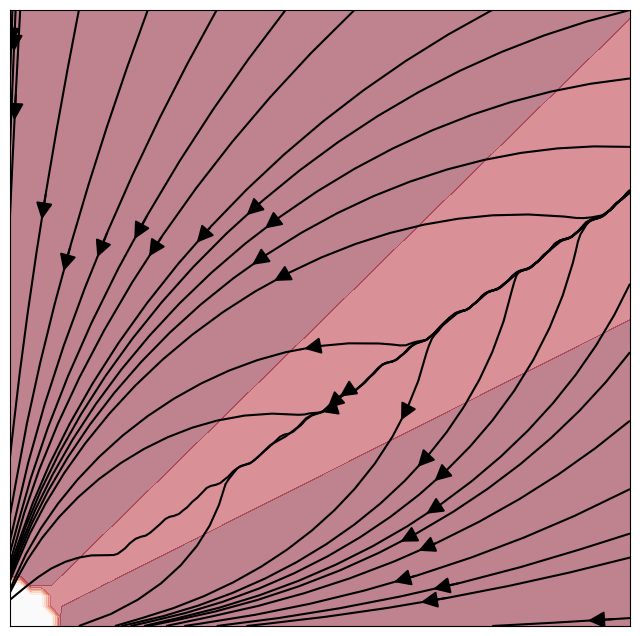

In [11]:

Direction_n2_x =  np.zeros((Npoints,Npoints))
Direction_n2_z =  np.zeros((Npoints,Npoints))
Std = np.zeros((Npoints,Npoints))

# Compute optimal direction
for i in range(X.shape[0]):
    for j in range(X.shape[0]):
        AgentPosition = np.array([Z[i,j], X[i,j], 0])
        if np.sqrt(X[i,j]**2 + Z[i,j]**2) < 0.5:
            Direction_n2_x[i,j] = 0
            Direction_n2_z[i,j] = 0
        else:
            _, _, e_2 = Define_gradient_eigenvectors(grad, e, AgentPosition)
            Direction_n2_x[i, j] = e_2[1]
            Direction_n2_z[i, j] = e_2[0]
            Std[i, j] = np.dot(e_2, -AgentPosition/np.linalg.norm(AgentPosition))
        
# Plot
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (8, 8), sharex = 'col', sharey = 'row')
axs.streamplot(X, Z, Direction_n2_x, Direction_n2_z, density = .35, color  = 'black', arrowsize = 2.5, broken_streamlines=False)
#axs.contour(X, Z, Std, cmap  = 'RdBu_r', alpha = .5)
levels = np.linspace(-1, 1.00001, 14)
im = axs.contourf(X, Z, Std, cmap = 'RdBu_r', levels = levels, vmin= -1, vmax = 1, alpha = 0.5)
# PlotCircles(axs, 0.6)
axs.set_xlim([0.1,5])
axs.set_ylim([0.1,5])
axs.set_xticks([])
axs.set_yticks([])
plt.savefig(f"Plots/Triangulation_theoretical_{grad_name}.pdf", bbox_inches='tight')

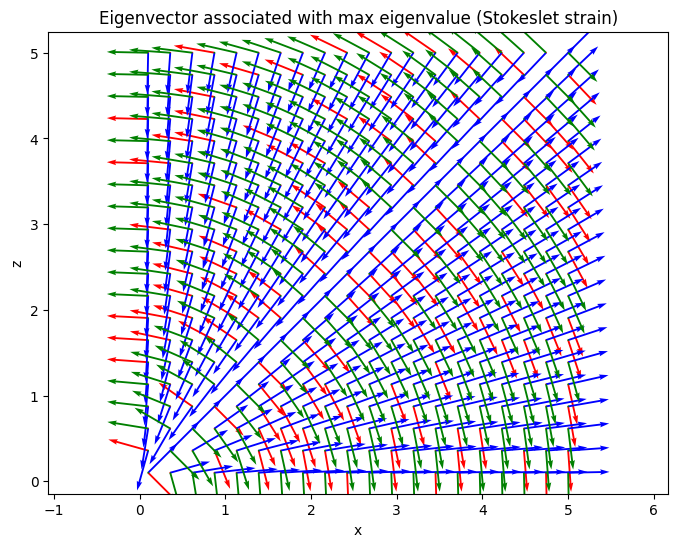

In [134]:

# Grid of points in x-z plane (y=0)
x_vals = np.linspace(0.1, 5, 20)
z_vals = np.linspace(0.1, 5, 20)
X, Z = np.meshgrid(x_vals, z_vals)

# Initialize arrays for plotting eigenvectors
U_e1 = np.zeros_like(X)  # x-component of vector e1
W_e1 = np.zeros_like(Z)  # z-component of vector e1

U_e2 = np.zeros_like(X)  # x-component of vector e1
W_e2 = np.zeros_like(Z)  # z-component of vector e1

U_e3 = np.zeros_like(X)  # x-component of vector e1
W_e3 = np.zeros_like(Z)  # z-component of vector e1

# Loop over points
for i in range(len(z_vals)):
    for j in range(len(x_vals)):
        AP = np.array([Z[i,j], X[i,j], 0])  # z,x,y
        G = GradientStokeslet(e, AP)
        # Symmetric part (strain tensor)
        E = 0.5*(G + G.T)
        # Eigenvalues and eigenvectors
        vals, vecs = np.linalg.eigh(E)
        # Pick eigenvector with largest eigenvalue
        max_idx = np.argmax(vals)
        v_max = vecs[:, max_idx]
        
        idx_sorted = np.argsort(np.abs(vals))[::-1]
        vals = vals[idx_sorted]
        vecs = vecs[:, idx_sorted]
        
        # Save x (index 0) and z (index 2) of e1
        U_e1[i,j] = v_max[1]  # x
        W_e1[i,j] = v_max[0]  # z

        # Save x (index 0) and z (index 2) of e2
        U_e2[i,j] = vecs[1, 1]  # x
        W_e2[i,j] = vecs[0, 1]  # z

        # Save x (index 0) and z (index 2) of e3
        U_e3[i,j] = vecs[1, 2]  # x
        W_e3[i,j] = vecs[0, 2]  # z



# Normalize vectors for plotting
norm = np.sqrt(U**2 + W**2)
U /= norm
W /= norm

# Plot
plt.figure(figsize=(8,6))
plt.quiver(X, Z, U_e2, W_e2,  color='r', scale=15)
plt.quiver(X, Z, U_e1, W_e1,  color='b', scale=15)
plt.quiver(X, Z, U_e3, W_e3,  color='g', scale=15)
plt.xlabel('x')
plt.ylabel('z')
plt.title('Eigenvector associated with max eigenvalue (Stokeslet strain)')
plt.axis('equal')
plt.show()